# 상품 inflow 전략 재검증 및 수익 레버 재설계

## 0. 배경

**(a)이전 2026 해커톤 프로젝트**
아정당 데이터를 이용해 상품(인터넷·모바일·렌탈)에서 inflow/상품 믹스를 조정해 월 수익을 얼마나 늘릴 수 있는지 본 분석.

**(b) 용어**
- **inflow**: 유입 경로 (전화예약상담, 바로상담, 랜딩페이지 등)
- **C→R→O→P**: 계약 → 가입완료 → 개통 → 수납완료 (PAYEND_CVR = P/C)
- **레버**: 같은 트래픽·예산 안에서 수익을 끌어올리기 위해 *무엇의 비중을 바꿀지* 정하는 축.
  - **inflow 믹스 레버** (인터넷·모바일): 같은 상품 안에서 저성과 inflow 비중 ↓ / 고성과 inflow 비중 ↑ — 예: 인터넷에서 전화예약상담 → 바로상담 유도
  - **상품 믹스 레버** (렌탈): 같은 inflow 안에서 저매출 서브상품 비중 ↓ / 고매출 서브상품 비중 ↑ — 예: 렌탈에서 정수기 계약 비중 강화

**(c) 사용 데이터 설명**
 유저 단위 로그가 아닌 각종 CVR,Inflow,상품 등의 월별 집계 데이터 (2024-03 ~ 2026-03). 

**(d) 이전 분석 결론**
인터넷 2.01억 + 모바일 0.24억 + 렌탈 0.22억 = **월 2.47억**. 단, *렌탈관련해서는 이번 분석에서 재검토 하지 않음*.

**(e) 이번 분석은**
인터넷 추정치를 기준 재정의로 보수적으로 재추정 **2.01억 → 1.30억**하고, 모바일은 트래픽 맥락을 추가 반영 **0.24억 → 0.54억**.


## 1. 프로젝트 개요

기존 상품 inflow 전략 분석은 **고성과 inflow로 트래픽을 이동시키면 전체 전환과 수익이 개선된다**는 전제 위에서 실행안과 기대효과를 제시하고 있었다. 하지만 실제로는 저성과 inflow의 부진 원인이 무엇인지, 그리고 고성과 inflow의 전환율이 이동된 유저에게도 그대로 재현되는지를 먼저 확인해야 했다.

이 프로젝트에서는 기존 분석의 전제를 다시 검증하고, 상품별로 inflow 전략을 **인터넷 / 모바일 / 렌탈** 기준으로 재정의했다.

### 핵심 결과
- **인터넷**: 바로가입 유도보다 **바로상담 유도**가 더 타당
- **모바일**: 단순 믹스 조정이 아니라 **방문고객 유도 + 혜택 공통화**가 핵심
- **렌탈**: 기존 레버 유지
- **보수 추정 기준 월 추가 매출 효과: 약 2.06억** (인터넷 1.3억 / 모바일 0.54억 (연 6.44억) / 렌탈 0.22억)
- **검증을 통해 초안 추정치 2.47억 → 2.06억으로 -17% 보수화** (기준 정정)


## 2. 문제 정의

기존 분석은 상품별 inflow 성과를 비교한 뒤, 저성과 inflow의 트래픽을 고성과 inflow로 이동시키는 전략을 제안했다.

하지만 이 접근은 두 가지 전제가 성립해야만 타당하다.

| # | 전제 |
|:---:|---|
| 1 | 저성과의 원인이 **공통 프로세스 병목**이 아니라 **inflow 구조 차이**인가? |
| 2 | 고성과 inflow로 유저를 이동시키면 그 inflow의 **전환율이 그대로 재현**되는가? |

즉, 단순히 **"어디가 CVR이 높은가"**만 보는 것이 아니라, **"왜 높은가 / 왜 낮은가 / 옮겨도 같은 결과가 나는가"**를 검증해야 했다.


## 3. 분석 설계

분석은 아래 4단계로 진행했다.

| 단계 | 내용 |
|---|---|
| **Step 1** 상품별 inflow 성과 비교 | 인터넷 / 모바일 / 렌탈의 inflow별 CVR · 매출 · 수익성 비교, 1차 레버 후보 도출 |
| **Step 2** 기존 전략의 전제 정의 | inflow 이동 전략이 성립하려면 필요한 **두 전제**를 명시 |
| **Step 3** 가설 검증 | 인터넷 — 저성과 원인이 콜센터인지/채널 단절인지<br>모바일 — 저관여 유입 혼합인지<br>모바일 보강 — 채널인지 혜택인지 |
| **Step 4** 실행안 재설계 및 기대효과 재산정 | 검증 결과 반영 → 상품별 레버 수정 → 기대효과 **보수적으로 재계산** |


In [1]:
# 전처리 — 공통 필터 + 상품×inflow groupby
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# 한글 폰트
for f in ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'DejaVu Sans']:
    try:
        mpl.rc('font', family=f)
        break
    except Exception:
        pass
mpl.rcParams['axes.unicode_minus'] = False

df4 = pd.read_csv('4번.csv')

EXCLUDED_PRODUCTS = ['상조', '부동산', '이사', '다이렉트자보']
df4 = df4[~df4['MAIN_CATEGORY_NAME'].isin(EXCLUDED_PRODUCTS)]
df4 = df4[df4['INFLOW_PATH_NAME'] != '재인입']

summary = df4.groupby(['MAIN_CATEGORY_NAME', 'INFLOW_PATH_NAME'], as_index=False).agg(
    contract_count=('CONTRACT_COUNT', 'sum'),
    payend_count=('PAYEND_COUNT', 'sum'),
    total_net_sales=('TOTAL_NET_SALES', 'sum'),
    active_months=('YEAR_MONTH', 'nunique'),
)
summary['payend_cvr'] = summary['payend_count'] / summary['contract_count'] * 100
summary['nspc'] = summary['total_net_sales'] / summary['contract_count']

print(f'분석 단위: {len(summary)} (상품×inflow)')
summary.head(3)


분석 단위: 242 (상품×inflow)


,MAIN_CATEGORY_NAME,INFLOW_PATH_NAME,contract_count,payend_count,total_net_sales,active_months,payend_cvr,nspc
0,기업용인터넷,CCTV랜딩,450,1,320000,9,0.222222,711.111111
1,기업용인터넷,그로스마케팅,105,0,0,4,0.000000,0.000000
2,기업용인터넷,기업용,504,1,0,2,0.198413,0.000000


### Step 1 — 상품×inflow 전체 풍경

상품 내부에서도 inflow별 PAYEND_CVR 편차가 크게 나타났다. 아래는 매출 상위 4개 상품 × 물량 상위 8개 inflow(미분류 제외)의 PAYEND_CVR heatmap이다. 상품이 달라도 **바로가입 / 바로상담 / 랜딩페이지 / 전화예약상담**이 공통으로 등장하며, 같은 inflow라도 상품별 성과가 다르다는 점이 바로 보인다.


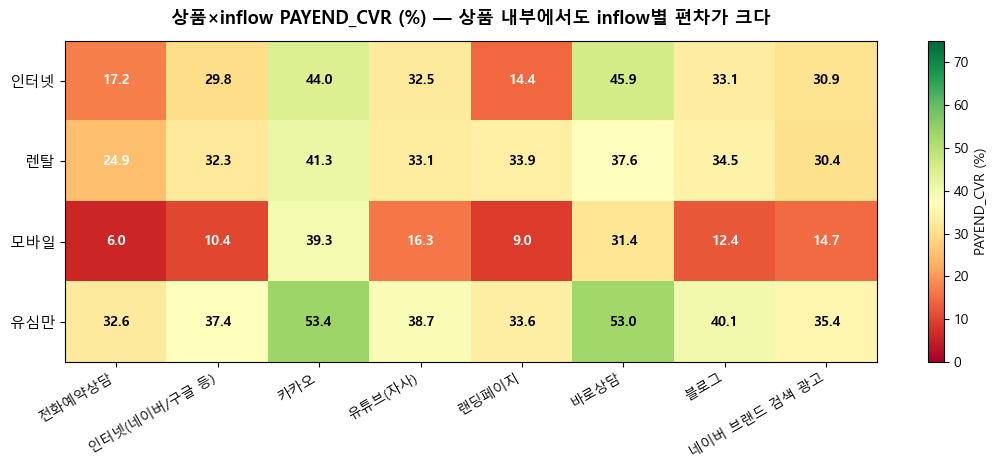

In [2]:
# Flagship 1 — 상품×inflow PAYEND_CVR 전체 분포 heatmap
top_products = (summary.groupby('MAIN_CATEGORY_NAME')['contract_count'].sum()
                .sort_values(ascending=False).head(4).index.tolist())

inflow_vol = summary.groupby('INFLOW_PATH_NAME')['contract_count'].sum().sort_values(ascending=False)
inflow_vol = inflow_vol[inflow_vol.index != '미분류']
top_inflows = inflow_vol.head(8).index.tolist()

pivot = (summary[summary['MAIN_CATEGORY_NAME'].isin(top_products) &
                 summary['INFLOW_PATH_NAME'].isin(top_inflows)]
         .pivot(index='MAIN_CATEGORY_NAME', columns='INFLOW_PATH_NAME', values='payend_cvr'))
pivot = pivot.reindex(index=top_products, columns=top_inflows)

fig, ax = plt.subplots(figsize=(11, 4.8))
im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=75)

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        v = pivot.values[i, j]
        if pd.notna(v):
            ax.text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=10,
                    color='white' if (v < 25 or v > 55) else 'black', fontweight='bold')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=30, ha='right', fontsize=10)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=11)
ax.set_title('상품×inflow PAYEND_CVR (%) — 상품 내부에서도 inflow별 편차가 크다',
             fontsize=13, fontweight='bold', pad=12)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('PAYEND_CVR (%)', fontsize=10)
plt.tight_layout()
plt.show()


## 4. 핵심 분석 결과

### 4-1. 인터넷: 핵심 병목은 콜센터가 아니라 상담 이후 등록 단계

3개 주력 상품(인터넷 · 모바일 · 렌탈)을 비교하면, 현재 주력 inflow와 상품 내부 상위 inflow 사이의 **PAYEND_CVR 갭**이 공통으로 관측된다. 특히 인터넷의 주력 inflow인 **전화예약상담**은 상품 내부 상위 3개 inflow 평균 대비 가장 큰 갭을 보였다.


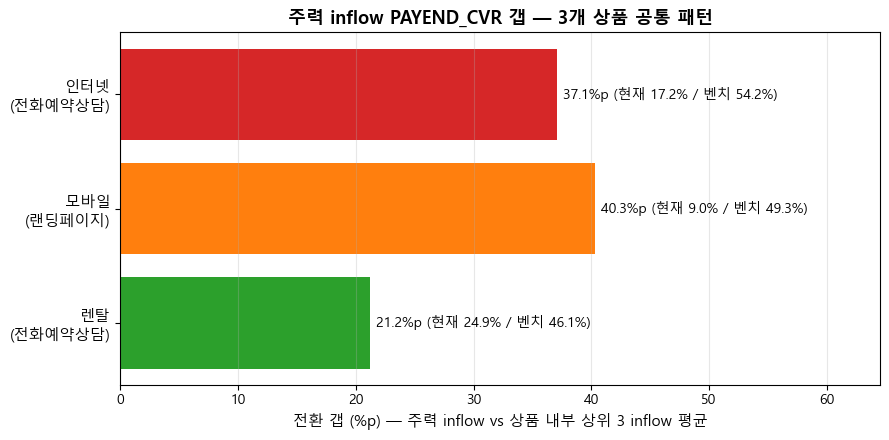

In [3]:
# Flagship 2 — Step 5 주력 inflow 갭 (3개 상품)
TARGETS = ['인터넷', '모바일', '렌탈']
CURRENT_MAIN = {'인터넷': '전화예약상담', '모바일': '랜딩페이지', '렌탈': '전화예약상담'}

gap_data = []
for market in TARGETS:
    mdf = summary[summary['MAIN_CATEGORY_NAME'] == market].copy()
    main_inflow = CURRENT_MAIN[market]
    main_cvr = mdf[mdf['INFLOW_PATH_NAME'] == main_inflow]['payend_cvr'].values[0]
    bench = (mdf[(mdf['INFLOW_PATH_NAME'] != main_inflow) & (mdf['active_months'] >= 6)]
             .nlargest(3, 'payend_cvr')['payend_cvr'].mean())
    gap_data.append({
        'market': f'{market}\n({main_inflow})',
        'current': main_cvr, 'bench': bench, 'gap': bench - main_cvr,
    })

gap_df = pd.DataFrame(gap_data)

fig, ax = plt.subplots(figsize=(9, 4.5))
y_pos = np.arange(len(gap_df))
bars = ax.barh(y_pos, gap_df['gap'], color=['#d62728', '#ff7f0e', '#2ca02c'])
ax.set_yticks(y_pos)
ax.set_yticklabels(gap_df['market'], fontsize=11)
ax.invert_yaxis()
ax.set_xlabel('전환 갭 (%p) — 주력 inflow vs 상품 내부 상위 3 inflow 평균', fontsize=11)
ax.set_title('주력 inflow PAYEND_CVR 갭 — 3개 상품 공통 패턴', fontsize=13, fontweight='bold')
for i, (g, c, b) in enumerate(zip(gap_df['gap'], gap_df['current'], gap_df['bench'])):
    ax.text(g + 0.5, i, f'{g:.1f}%p (현재 {c:.1f}% / 벤치 {b:.1f}%)',
            va='center', fontsize=10)
ax.set_xlim(0, gap_df['gap'].max() * 1.6)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


기존에는 인터넷 전화예약상담 inflow의 저성과가 **콜센터 문제**일 수 있다고 볼 여지가 있었다. 하지만 단계별 전환을 쪼개서 보니, 문제는 콜센터 자체보다 **상담 이후 등록 단계(C→R)** 에 있었다.

**핵심 결과**
- 전화예약상담과 바로상담의 최종 C→P 격차는 **28.7%p**
- 그런데 이보다 더 큰 **34.7%p** 차이가 이미 **C→R 단계에서 먼저 발생**
- 이후 단계(R→O, O→P)는 상대적으로 안정적
- 참고로 콜센터 자체 성과는 문제 없음 — 가중평균 연결률 **97.37%**, 시간대 IQR 1.1%p

**해석**
인터넷 inflow의 저성과는 **상담 이후 등록 과정에서의 채널 단절**이 핵심 원인이었다. 따라서 인터넷에서는 **바로가입 유도보다, 같은 상담 세그먼트 안에서 바로상담으로 유도하는 전략**이 더 타당하다.


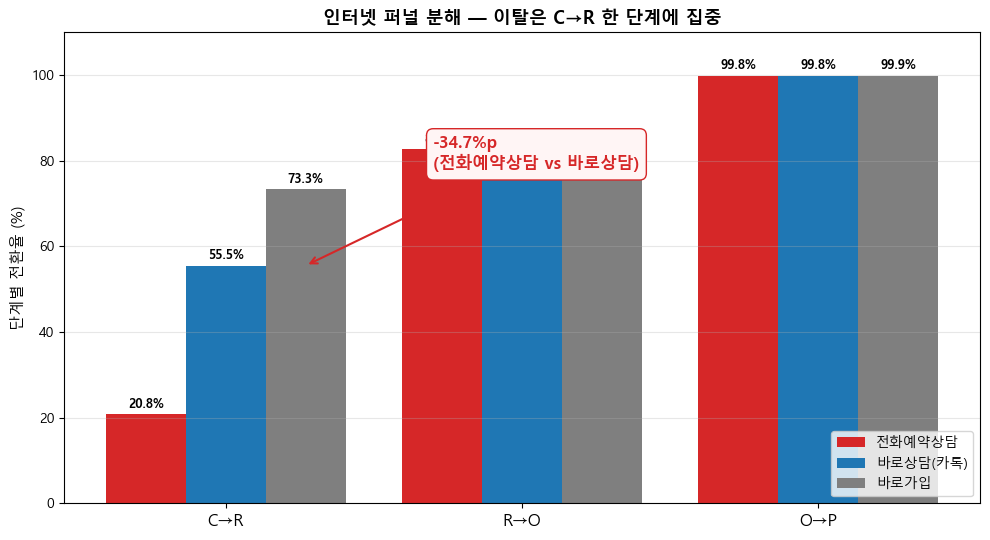

In [4]:
# Flagship 3 — 인터넷 퍼널 분해 (C→R 격차 시각화)
INTERNET_INFLOWS_DATA = ['전화예약상담', '바로상담', '바로가입']
DISPLAY_LABEL = {'전화예약상담': '전화예약상담',
                 '바로상담': '바로상담(카톡)',
                 '바로가입': '바로가입'}

idf = df4[(df4['MAIN_CATEGORY_NAME'] == '인터넷') &
          (df4['INFLOW_PATH_NAME'].isin(INTERNET_INFLOWS_DATA))].copy()
funnel = idf.groupby('INFLOW_PATH_NAME', as_index=False).agg(
    contract=('CONTRACT_COUNT', 'sum'),
    registend=('REGISTEND_COUNT', 'sum'),
    open_=('OPEN_COUNT', 'sum'),
    payend=('PAYEND_COUNT', 'sum'),
)
funnel['C_to_R'] = funnel['registend'] / funnel['contract'] * 100
funnel['R_to_O'] = funnel['open_'] / funnel['registend'] * 100
funnel['O_to_P'] = funnel['payend'] / funnel['open_'] * 100
funnel = funnel.set_index('INFLOW_PATH_NAME').reindex(INTERNET_INFLOWS_DATA)

stages = ['C→R', 'R→O', 'O→P']
x = np.arange(len(stages))
width = 0.27

fig, ax = plt.subplots(figsize=(10, 5.5))
colors = {'전화예약상담': '#d62728', '바로상담': '#1f77b4', '바로가입': '#7f7f7f'}
for i, inflow in enumerate(INTERNET_INFLOWS_DATA):
    vals = [funnel.loc[inflow, 'C_to_R'], funnel.loc[inflow, 'R_to_O'], funnel.loc[inflow, 'O_to_P']]
    bars = ax.bar(x + (i - 1) * width, vals, width,
                  label=DISPLAY_LABEL[inflow], color=colors[inflow])
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 1.5, f'{v:.1f}%',
                ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(stages, fontsize=12)
ax.set_ylabel('단계별 전환율 (%)', fontsize=11)
ax.set_title('인터넷 퍼널 분해 — 이탈은 C→R 한 단계에 집중',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.3)

gap = funnel.loc['바로상담', 'C_to_R'] - funnel.loc['전화예약상담', 'C_to_R']
ax.annotate(f'-{gap:.1f}%p\n(전화예약상담 vs 바로상담)',
            xy=(0 + width, funnel.loc['바로상담', 'C_to_R']),
            xytext=(0.7, 78),
            fontsize=12, color='#d62728', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#d62728', lw=1.5),
            bbox=dict(boxstyle='round,pad=0.4', fc='#fff5f5', ec='#d62728'))
plt.tight_layout()
plt.show()


#### 기준 재선정 — 동등 세그먼트 비교로 보수화

인터넷 기대효과 재산정 과정에서 **바로가입(PAYEND_CVR 73.3%)**을 유도 목표로 삼으면 추정이 부풀 수 있다는 점이 드러났다. 바로가입은 "상담 없이 바로 가입"을 택한 유저의 성과라, 상담을 거치는 유저에게 그대로 재현된다고 보기 어렵다.

| 비교 세그먼트 | PAYEND_CVR | 비고 |
|---|---:|---|
| 바로가입 | **73.3%** | "상담 없이 바로 가입" — 선택 편향 세그먼트 |
| 바로상담(카톡) | **55.5%** | 상담 유저 — **동등 비교군** |
| 전화예약상담 (현재) | 16.80% | baseline |

**보정 로직**
- 바로가입 변화량 (원 기준): 60.09% − 16.80% = **43.29%p**
- 바로상담 변화량 (정정 기준): 46.23% − 16.80% = **29.43%p**
- 변화량 비율: 29.43 / 43.29 = **0.680**
- 인터넷 재추정: 월 2.01억 × 0.680 ≈ **월 1.30억** (원 분석 대비 -35%)

> 이 보정을 통해 초안에서 내가 세운 기대효과를 한 번 더 검증하고 보수화했다. **"고성과 inflow로 옮기면 같은 CVR이 재현된다"**는 전제를 무비판적으로 적용하지 않은 것이 본 분석의 차별점이다.


### 4-2. 모바일: 저성과의 핵심은 프로세스보다 저관여 유입 혼합

모바일 랜딩페이지의 PAYEND_CVR은 낮았지만, 인터넷처럼 별도 상담 단계가 없었다. 따라서 모바일은 다른 원인으로 봐야 했다.

**핵심 결과**
- 저관여 채널(organic + display) CONSULT_CVR: **0.84%**
- 고관여 채널(brandsearch + sa) CONSULT_CVR: **16.2%**
- 약 **19배** 차이
- 또한 랜딩페이지 inflow는 **트래픽이 많을 때 CVR이 낮고, 트래픽이 줄면 CVR이 급등**하는 패턴 (8.7% → 54%, 6배)

**해석**
모바일 랜딩 저성과는 단순한 프로세스 문제라기보다, **저관여(low-intent) 유저가 대량 섞여 평균 CVR이 희석된 구조**로 보는 것이 더 타당했다. 즉 모바일에서는 고CVR inflow 평균을 그대로 가져와 랜딩 유저에게 적용하면 과대추정될 가능성이 있다.


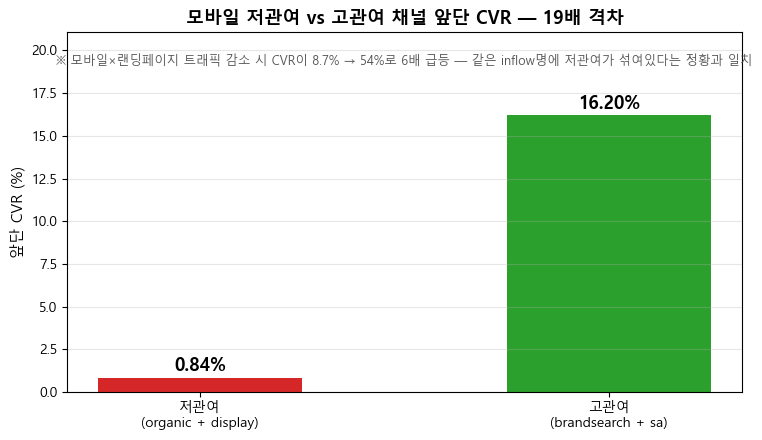

In [5]:
# Flagship 4 — 모바일 저관여 vs 고관여 앞단 CVR 19배
ch_cvr = pd.DataFrame({
    'category': ['저관여\n(organic + display)', '고관여\n(brandsearch + sa)'],
    'cvr': [0.84, 16.20],
})
ratio = ch_cvr.loc[1, 'cvr'] / ch_cvr.loc[0, 'cvr']

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(ch_cvr['category'], ch_cvr['cvr'],
              color=['#d62728', '#2ca02c'], width=0.5)
for b, v in zip(bars, ch_cvr['cvr']):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.4, f'{v:.2f}%',
            ha='center', fontsize=13, fontweight='bold')

ax.set_ylabel('앞단 CVR (%)', fontsize=11)
ax.set_title(f'모바일 저관여 vs 고관여 채널 앞단 CVR — {ratio:.0f}배 격차',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, ch_cvr['cvr'].max() * 1.3)
ax.grid(axis='y', alpha=0.3)

ax.text(0.5, ch_cvr['cvr'].max() * 1.18,
        '※ 모바일×랜딩페이지 트래픽 감소 시 CVR이 8.7% → 54%로 6배 급등 — '
        '같은 inflow명에 저관여가 섞여있다는 정황과 일치',
        ha='center', fontsize=9, style='italic', color='#555',
        transform=ax.transData)
plt.tight_layout()
plt.show()


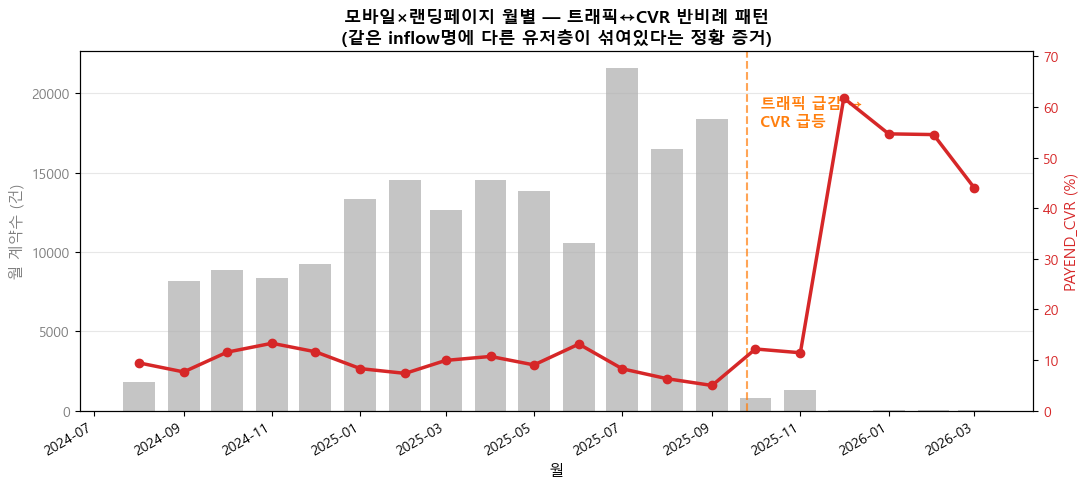

In [6]:
# 모바일×랜딩페이지 월별 — 트래픽↔CVR 반비례 시각화
m = df4[(df4['MAIN_CATEGORY_NAME'] == '모바일') & (df4['INFLOW_PATH_NAME'] == '랜딩페이지')].copy()
m['YEAR_MONTH'] = pd.to_datetime(m['YEAR_MONTH'])
monthly = m.groupby('YEAR_MONTH', as_index=False).agg(
    contract=('CONTRACT_COUNT', 'sum'),
    payend=('PAYEND_COUNT', 'sum'),
)
# 운영 안정기 (2024-08부터, 초기 노이즈 제외)
monthly = monthly[monthly['YEAR_MONTH'] >= '2024-08-01'].sort_values('YEAR_MONTH').reset_index(drop=True)
monthly['payend_cvr'] = monthly['payend'] / monthly['contract'] * 100

fig, ax1 = plt.subplots(figsize=(11, 5))
color1 = '#7f7f7f'
color2 = '#d62728'

ax1.bar(monthly['YEAR_MONTH'], monthly['contract'], width=22,
        color=color1, alpha=0.45, label='월 계약수')
ax1.set_xlabel('월', fontsize=11)
ax1.set_ylabel('월 계약수 (건)', color=color1, fontsize=11)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
ax2.plot(monthly['YEAR_MONTH'], monthly['payend_cvr'],
         color=color2, marker='o', linewidth=2.5, label='PAYEND_CVR')
ax2.set_ylabel('PAYEND_CVR (%)', color=color2, fontsize=11)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0, monthly['payend_cvr'].max() * 1.15)

# 트래픽 급감 시점 표시 (2025-09 → 2025-10 사이)
ax1.axvline(pd.to_datetime('2025-09-25'), color='#ff7f0e', linestyle='--', alpha=0.7, lw=1.5)
ax1.text(pd.to_datetime('2025-10-01'), monthly['contract'].max() * 0.92,
         ' 트래픽 급감 →\n CVR 급등',
         fontsize=11, color='#ff7f0e', fontweight='bold', va='top')

ax1.set_title('모바일×랜딩페이지 월별 — 트래픽↔CVR 반비례 패턴\n(같은 inflow명에 다른 유저층이 섞여있다는 정황 증거)',
              fontsize=12.5, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


### 4-3. 모바일 보강: 저관여 유저 전환에는 채널보다 혜택 요인이 더 크게 작용

모바일에서 단순 inflow 교체가 어렵다면, **저관여 유저가 무엇 때문에 전환했는지**를 다시 봐야 했다.

**핵심 결과**
- 2025-02~09 저관여 계약 중 **pmax + 당근 배너가 48%** 차지
- 순수 저관여 채널 계약 CVR: **0.28%**
- 혜택 위주 광고 계약 CVR: **6.76%**
- 약 **24배** 차이
- 모바일 × 사전예약이벤트 PAYEND_CVR **20.9%** (랜딩 8.5% 대비 2.5배)

**해석**
저관여 유저 전환에는 inflow 채널 자체보다 **혜택(가격·할인·프로모션) 요인**이 더 크게 작용했을 가능성이 높았다. 즉 모바일 레버는 단순한 inflow 이동이 아니라, **혜택을 유지한 채 더 전환력이 높은 inflow로 유도**하는 방식이어야 했다.

> **참고**: 일부 성과 차이는 혜택 메시지뿐 아니라 매체 타기팅 효과도 함께 반영됐을 가능성이 있어, 혜택 효과는 **정황 증거 수준**으로 해석했다.


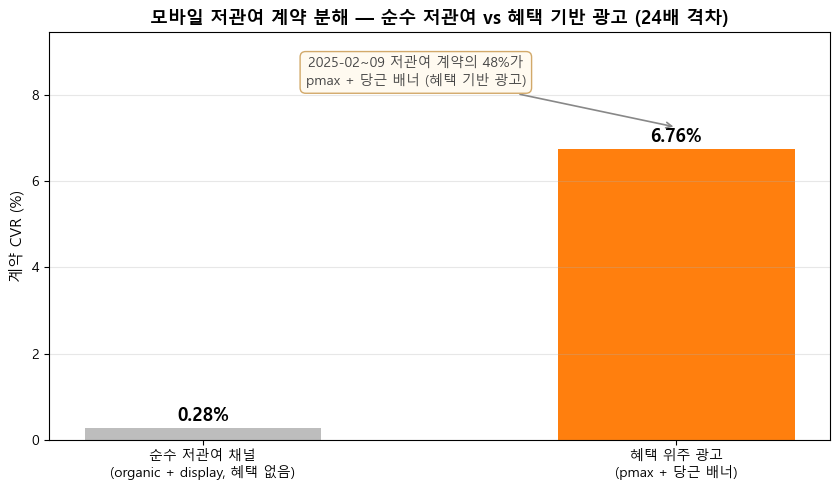

In [7]:
# 가설 D — 혜택 위주 광고 vs 순수 저관여 채널 CVR
benefit_vs_low = pd.DataFrame({
    'category': ['순수 저관여 채널\n(organic + display, 혜택 없음)',
                 '혜택 위주 광고\n(pmax + 당근 배너)'],
    'cvr': [0.28, 6.76],
})
ratio2 = benefit_vs_low.loc[1, 'cvr'] / benefit_vs_low.loc[0, 'cvr']

fig, ax = plt.subplots(figsize=(8.5, 5))
bars = ax.bar(benefit_vs_low['category'], benefit_vs_low['cvr'],
              color=['#bdbdbd', '#ff7f0e'], width=0.5)
for b, v in zip(bars, benefit_vs_low['cvr']):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.15, f'{v:.2f}%',
            ha='center', fontsize=13, fontweight='bold')

ax.set_ylabel('계약 CVR (%)', fontsize=11)
ax.set_title(f'모바일 저관여 계약 분해 — 순수 저관여 vs 혜택 기반 광고 ({ratio2:.0f}배 격차)',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, benefit_vs_low['cvr'].max() * 1.4)
ax.grid(axis='y', alpha=0.3)

# 48% 기여비중 주석 — 혜택 막대를 가리키는 화살표
ax.annotate('2025-02~09 저관여 계약의 48%가\npmax + 당근 배너 (혜택 기반 광고)',
            xy=(1, benefit_vs_low.loc[1, 'cvr'] + 0.5),
            xytext=(0.45, benefit_vs_low['cvr'].max() * 1.22),
            fontsize=10, color='#444', ha='center',
            arrowprops=dict(arrowstyle='->', color='#888', lw=1.2),
            bbox=dict(boxstyle='round,pad=0.4', fc='#fffaf0', ec='#d2a96a'))
plt.tight_layout()
plt.show()


## 5. 인사이트

이 프로젝트에서 가장 중요했던 인사이트는 다음 3가지다.

### 1) 고성과 inflow가 있다고 해서, 저성과 inflow 유저를 옮기면 같은 전환율이 재현되는 것은 아니다
기존 분석은 **"성과가 좋은 inflow = 옮기면 좋은 inflow"**로 해석했지만, 실제로는 inflow별 성과 차이 뒤에 **유저 특성과 프로세스 구조 차이**가 있었다.

### 2) 같은 믹스 조정 문제처럼 보여도, 인터넷과 모바일의 병목 원인은 달랐다
- **인터넷**: 채널 단절이 핵심 병목
- **모바일**: 저관여 유입 혼합이 핵심 병목

즉 같은 "전환 개선" 문제라도, **시장별로 전혀 다른 레버**가 필요했다.

### 3) 모바일은 단순 inflow 교체가 아니라 '유도 + 혜택 공통화'의 결합 전략이 필요했다
모바일의 저관여 유저는 **방문고객 inflow의 대면 응대 강점**과 **혜택 공통화**가 함께 작동할 때만 전환 가능성이 생긴다.


## 6. 액션 제안

분석 결과를 바탕으로 상품별 액션을 다음처럼 재설계했다.

| 시장 | 액션 | 이유 |
|---|---|---|
| **인터넷** | 전화예약상담 → **바로상담 유도** | 핵심 병목이 **상담 이후 등록 단계의 채널 단절**이기 때문 |
| **모바일** | 랜딩페이지 → **방문고객 inflow 유도 + 혜택 공통화** | 단순 inflow 교체만으로는 전환율 재현이 어렵고, 혜택 반응형 유저에게는 추가 전환 레버가 필요 |
| **렌탈** | **기존 수익 개선 레버 유지** | 97% contract→payend CVR로 현 상태 안정 |


## 7. 기대효과

보수적으로 추정한 월 추가 매출 효과는 아래와 같다. **초안 단계에서 산출했던 2.47억은 고성과 inflow의 CVR을 그대로 대입한 수치였지만, 가설 검증 후 동등 비교군으로 기준을 교체해 2.06억으로 보수화**했다.


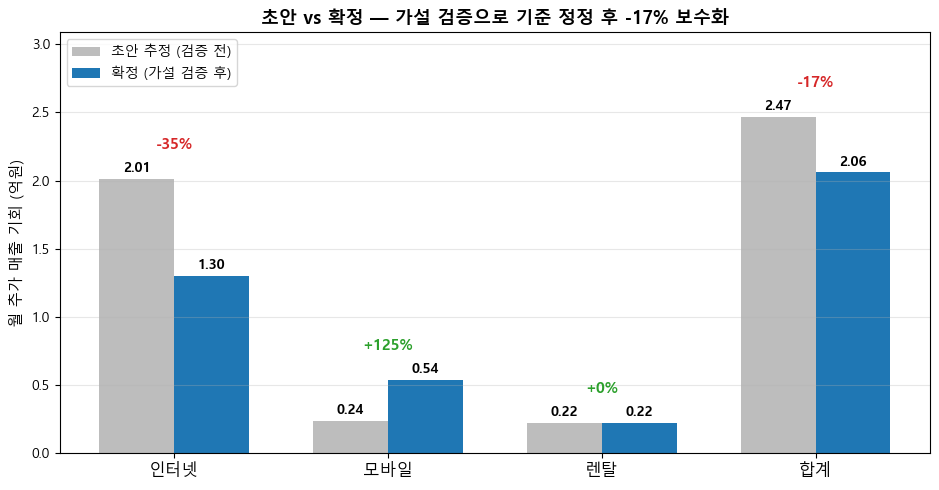

In [8]:
# Flagship 5 — 원 분석 vs 확정 기대 수익 (Before / After)
revenue = pd.DataFrame({
    'market': ['인터넷', '모바일', '렌탈', '합계'],
    'original': [2.01, 0.24, 0.22, 2.47],
    'final':    [1.30, 0.54, 0.22, 2.06],
})

x = np.arange(len(revenue['market']))
width = 0.35

fig, ax = plt.subplots(figsize=(9.5, 5))
b1 = ax.bar(x - width / 2, revenue['original'], width,
            label='초안 추정 (검증 전)', color='#bdbdbd')
b2 = ax.bar(x + width / 2, revenue['final'], width,
            label='확정 (가설 검증 후)', color='#1f77b4')

for bars in [b1, b2]:
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.05,
                f'{b.get_height():.2f}', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(revenue['market'], fontsize=12)
ax.set_ylabel('월 추가 매출 기회 (억원)', fontsize=11)
ax.set_title('초안 vs 확정 — 가설 검증으로 기준 정정 후 -17% 보수화',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.set_ylim(0, max(revenue['original'].max(), revenue['final'].max()) * 1.25)
ax.grid(axis='y', alpha=0.3)

for i, (o, f) in enumerate(zip(revenue['original'], revenue['final'])):
    pct = (f - o) / o * 100
    color = '#d62728' if pct < 0 else '#2ca02c'
    ax.text(i, max(o, f) + 0.22, f'{pct:+.0f}%',
            ha='center', color=color, fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()


### 기대효과 표

| 상품 | 액션 | 월 추가 매출 효과 |
|---|---|---:|
| 인터넷 | 전화예약상담 → 바로상담 유도 | **1.30억** |
| 모바일 | 랜딩 → 방문고객 유도 + 혜택 공통화 | **0.54억** (연 6.44억) |
| 렌탈 | 기존 레버 유지 | **0.22억** |
| **합계** | | **2.06억** |

### 산정 근거

**인터넷 1.30억 — 기준 정정 기반 비율 보정**
- 전화예약상담 PAYEND_CVR: 16.80% (baseline)
- 바로가입 변화량: 60.09% − 16.80% = **43.29%p** (원 기준, 선택 편향)
- 바로상담 변화량: 46.23% − 16.80% = **29.43%p** (정정 기준, 동등 비교군)
- 비율: 29.43 / 43.29 = **0.680**
- 계산: 월 2.01억 × 0.680 ≈ 월 1.37억 → 보수적으로 **월 1.30억**

**모바일 0.54억 — 혜택 기반 직접 모델**
- 모바일 × 랜딩페이지 월 평균 계약: 13,023건 (2025-02 ~ 09 고트래픽 구간)
- 유도 대상: 랜딩 물량의 **10%** = 월 1,302건
- 현재 랜딩 CVR: 9.0% / 유도 후 달성 CVR: **21%** (사전예약이벤트 20.9% 실측 기준)
- PAYEND당 평균 매출: 345,062원
- 계산: 1,302 × (21% − 9%) × 345,062원 ≈ **월 0.54억** (연 6.44억)

> 두 산정 모두 **파일럿으로 실집행 효율을 확정**해야 한다. 본 값은 비율 보정 / 실측값 기준 추정치이며, 실제 방문고객 inflow의 더 높은 CVR과 객단가 상승 효과는 반영하지 않은 **보수 추정치**다.


## 8. 한계 및 회고

### 한계
1. **표본 제약** — 일부 구간은 표본이 작아 정황 증거 수준으로 해석했다
2. **혜택 vs 매체 타겟팅 혼재** — 모바일 혜택 효과에는 매체 타기팅 효과가 함께 반영됐을 가능성이 있다
3. **집행 전 검증 필요** — 실제 집행 전에는 A/B 테스트나 운영 실험으로 추가 검증이 필요하다
4. **인터넷 1.30억의 실증 범위** — 기준 교체에 따른 비율 보정값이며, 실집행 시 바로상담 유도 효율은 다른 분석으로 확정 필요
5. **CVR 개선 레버의 확장 한계** — 인터넷 · 렌탈은 혜택 조작 변수 부재로 모바일처럼 혜택 기반 접근 확장 불가

### 회고
기존에 분석을 더 자세히, 그 전략이 성립하는 전제까지 최대한 검증해본 분석이었다.

특히 같은 전환 개선 문제라도 **인터넷은 프로세스 마찰형**, **모바일은 혜택 반응형 유입 재배치형**으로 전혀 다른 접근이 필요하다는 점이 핵심 인사이트였다. 또한 초안에서 산출한 기대효과 2.47억을 그대로 결론 내지 않고, **선택 편향을 식별해 기준을 교체함으로써 2.06억으로 보수화**한 것이 스스로 분석에 대한 신뢰도를 높이는 과정이었다.

